In [4]:
# ============================================================
# CELL 1 — Setup & Load Prepared Data
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid", palette="muted")

# Reload and reprocess data
df = pd.read_csv('../data/Leads.csv')
df_clean = df.copy()

# Drop columns
drop_cols = [
    'Prospect ID', 'Lead Number', 'Lead Quality',
    'Asymmetrique Activity Index', 'Asymmetrique Profile Index',
    'How did you hear about X Education',
    'I agree to pay the amount through cheque',
    'Get updates on DM Content', 'Update me on Supply Chain Content',
    'Receive More Updates About Our Courses'
]
df_clean.drop(columns=drop_cols, inplace=True)

# Fill numeric
for col in ['TotalVisits', 'Page Views Per Visit',
            'Asymmetrique Activity Score', 'Asymmetrique Profile Score']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill binary
binary_cols = [
    'Do Not Email', 'Do Not Call', 'Search', 'Magazine',
    'Newspaper Article', 'X Education Forums', 'Newspaper',
    'Digital Advertisement', 'Through Recommendations',
    'A free copy of Mastering The Interview'
]
for col in binary_cols:
    df_clean[col] = df_clean[col].fillna('No')

# Fill categorical
cat_cols = [
    'Lead Source', 'Last Activity', 'Country', 'Specialization',
    'What is your current occupation',
    'What matters most to you in choosing a course',
    'Tags', 'Lead Profile', 'City', 'Last Notable Activity'
]
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Replace Select
df_clean = df_clean.replace('Select', np.nan)
for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Feature engineering
def response_time_bucket(time):
    if time == 0: return 'No Engagement'
    elif time <= 300: return 'Low (0-5 min)'
    elif time <= 900: return 'Medium (5-15 min)'
    else: return 'High (15+ min)'

df_clean['Engagement_Level'] = df_clean['Total Time Spent on Website'].apply(response_time_bucket)
df_clean['High_Interaction'] = (df_clean['TotalVisits'] >= 5).astype(int)

def group_lead_source(source):
    if source in ['Google', 'Organic Search', 'Bing']: return 'Search Engine'
    elif source in ['Direct Traffic', 'NC_EDM']: return 'Direct'
    elif source in ['Olark Chat', 'Live Chat']: return 'Chat'
    elif source in ['WeLearn', 'Welingak Website']: return 'Partner'
    elif source in ['Reference', 'Through Recommendations']: return 'Referral'
    elif source in ['Social Media', 'Facebook', 'youtube']: return 'Social'
    else: return 'Other'

df_clean['Lead_Source_Group'] = df_clean['Lead Source'].apply(group_lead_source)
df_clean['Is_Webinar_Lead'] = (df_clean['Lead Source'] == 'Webinar').astype(int)
df_clean['Engagement_Score'] = (
    df_clean['Total Time Spent on Website'] * 0.5 +
    df_clean['TotalVisits'] * 10 +
    df_clean['Page Views Per Visit'] * 5
)

# Encode
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

engagement_order = {
    'No Engagement': 0, 'Low (0-5 min)': 1,
    'Medium (5-15 min)': 2, 'High (15+ min)': 3
}
df_clean['Engagement_Level'] = df_clean['Engagement_Level'].map(engagement_order)

ohe_cols = [
    'Lead Origin', 'Lead Source', 'Last Activity', 'Country',
    'Specialization', 'What is your current occupation',
    'What matters most to you in choosing a course',
    'Tags', 'Lead Profile', 'City', 'Lead_Source_Group',
    'Last Notable Activity'
]
df_encoded = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=True)

# Split and SMOTE
X = df_encoded.drop(columns=['Converted'])
y = df_encoded['Converted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Data loaded and preprocessed successfully.")
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples: {X_test_scaled.shape[0]}")
print(f"Features: {X_train_scaled.shape[1]}")
print("\nReady for model training!")

Data loaded and preprocessed successfully.
Training samples: 9086
Test samples: 1848
Features: 175

Ready for model training!


In [5]:
# ============================================================
# CELL 2 — Train All Four Models
# ============================================================

from sklearn.model_selection import cross_val_score

results = {}

# ── Model 1: Logistic Regression (Linear Baseline) ──
print("Training Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_smote)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
results['Logistic Regression'] = {
    'model': lr,
    'predictions': lr_pred,
    'probabilities': lr_prob,
    'auc': roc_auc_score(y_test, lr_prob),
    'f1': f1_score(y_test, lr_pred),
    'accuracy': accuracy_score(y_test, lr_pred)
}
print(f"Done. AUC-ROC: {results['Logistic Regression']['auc']:.4f}")

# ── Model 2: Random Forest (Tree-based Ensemble) ──
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]
results['Random Forest'] = {
    'model': rf,
    'predictions': rf_pred,
    'probabilities': rf_prob,
    'auc': roc_auc_score(y_test, rf_prob),
    'f1': f1_score(y_test, rf_pred),
    'accuracy': accuracy_score(y_test, rf_pred)
}
print(f"Done. AUC-ROC: {results['Random Forest']['auc']:.4f}")

# ── Model 3: XGBoost (Gradient Boosting) ──
print("\nTraining XGBoost...")
xgb = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train_smote, y_train_smote)
xgb_pred = xgb.predict(X_test_scaled)
xgb_prob = xgb.predict_proba(X_test_scaled)[:, 1]
results['XGBoost'] = {
    'model': xgb,
    'predictions': xgb_pred,
    'probabilities': xgb_prob,
    'auc': roc_auc_score(y_test, xgb_prob),
    'f1': f1_score(y_test, xgb_pred),
    'accuracy': accuracy_score(y_test, xgb_pred)
}
print(f"Done. AUC-ROC: {results['XGBoost']['auc']:.4f}")

# ── Model 4: SVM (Kernel Method) ──
print("\nTraining SVM (this may take a minute)...")
svm = SVC(probability=True, random_state=42, kernel='rbf')
svm.fit(X_train_scaled, y_train_smote)
svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]
results['SVM'] = {
    'model': svm,
    'predictions': svm_pred,
    'probabilities': svm_prob,
    'auc': roc_auc_score(y_test, svm_prob),
    'f1': f1_score(y_test, svm_pred),
    'accuracy': accuracy_score(y_test, svm_pred)
}
print(f"Done. AUC-ROC: {results['SVM']['auc']:.4f}")

# ── Summary Table ──
print("\n=== MODEL COMPARISON SUMMARY ===")
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC-ROC': [results[m]['auc'] for m in results],
    'F1 Score': [results[m]['f1'] for m in results],
    'Accuracy': [results[m]['accuracy'] for m in results]
}).sort_values('AUC-ROC', ascending=False)
print(summary.to_string(index=False))


Training Logistic Regression...
Done. AUC-ROC: 0.9510

Training Random Forest...
Done. AUC-ROC: 0.9068

Training XGBoost...
Done. AUC-ROC: 0.8046

Training SVM (this may take a minute)...
Done. AUC-ROC: 0.9486

=== MODEL COMPARISON SUMMARY ===
              Model  AUC-ROC  F1 Score  Accuracy
Logistic Regression 0.951050  0.857345  0.890693
                SVM 0.948557  0.861230  0.895022
      Random Forest 0.906815  0.754098  0.813312
            XGBoost 0.804586  0.221393  0.661255


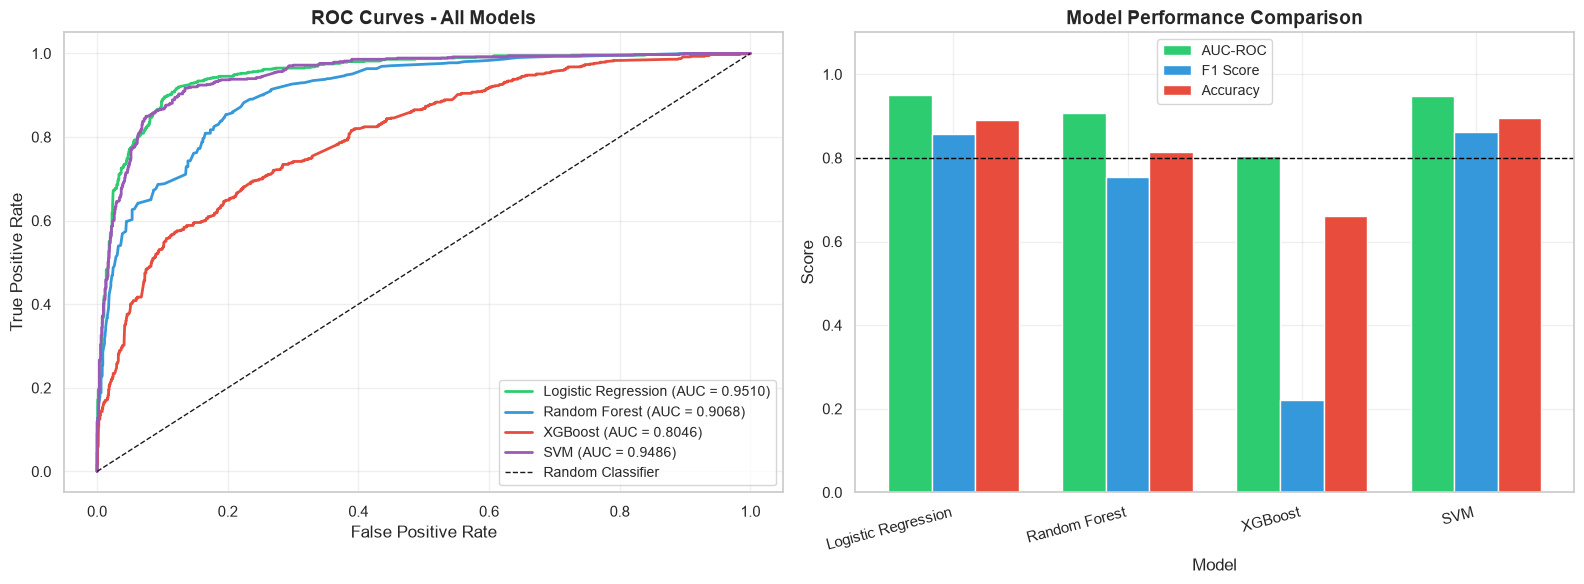

Chart saved.


In [6]:
# ============================================================
# CELL 3 — ROC Curves & Visual Comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - ROC Curves for all models
colors = ['#2ECC71', '#3498DB', '#E74C3C', '#9B59B6']
for (name, result), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                label=f"{name} (AUC = {result['auc']:.4f})")

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2 - Model comparison bar chart
metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC-ROC': [results[m]['auc'] for m in results],
    'F1 Score': [results[m]['f1'] for m in results],
    'Accuracy': [results[m]['accuracy'] for m in results]
})

x = np.arange(len(metrics_df['Model']))
width = 0.25
axes[1].bar(x - width, metrics_df['AUC-ROC'], width, label='AUC-ROC', color='#2ECC71', edgecolor='white')
axes[1].bar(x, metrics_df['F1 Score'], width, label='F1 Score', color='#3498DB', edgecolor='white')
axes[1].bar(x + width, metrics_df['Accuracy'], width, label='Accuracy', color='#E74C3C', edgecolor='white')
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_df['Model'], rotation=15, ha='right')
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].axhline(y=0.80, color='black', linestyle='--', linewidth=1, label='Target (0.80)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [7]:
# ============================================================
# CELL 4 — XGBoost Hyperparameter Tuning
# ============================================================

from sklearn.model_selection import GridSearchCV

print("Tuning XGBoost — this may take 3-5 minutes...")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'scale_pos_weight': [1, 2]
}

xgb_tune = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)

grid_search = GridSearchCV(
    xgb_tune,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV AUC-ROC: {grid_search.best_score_:.4f}")

# Evaluate tuned model
xgb_best = grid_search.best_estimator_
xgb_best_pred = xgb_best.predict(X_test_scaled)
xgb_best_prob = xgb_best.predict_proba(X_test_scaled)[:, 1]

print(f"\nTuned XGBoost on Test Set:")
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_best_prob):.4f}")
print(f"F1 Score: {f1_score(y_test, xgb_best_pred):.4f}")
print(f"Accuracy: {accuracy_score(y_test, xgb_best_pred):.4f}")

# Update results
results['XGBoost Tuned'] = {
    'model': xgb_best,
    'predictions': xgb_best_pred,
    'probabilities': xgb_best_prob,
    'auc': roc_auc_score(y_test, xgb_best_prob),
    'f1': f1_score(y_test, xgb_best_pred),
    'accuracy': accuracy_score(y_test, xgb_best_pred)
}

print("\n=== UPDATED MODEL SUMMARY ===")
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC-ROC': [results[m]['auc'] for m in results],
    'F1 Score': [results[m]['f1'] for m in results],
    'Accuracy': [results[m]['accuracy'] for m in results]
}).sort_values('AUC-ROC', ascending=False)
print(summary.to_string(index=False))

Tuning XGBoost — this may take 3-5 minutes...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 2}
Best CV AUC-ROC: 0.9778

Tuned XGBoost on Test Set:
AUC-ROC: 0.8118
F1 Score: 0.2346
Accuracy: 0.6645

=== UPDATED MODEL SUMMARY ===
              Model  AUC-ROC  F1 Score  Accuracy
Logistic Regression 0.951050  0.857345  0.890693
                SVM 0.948557  0.861230  0.895022
      Random Forest 0.906815  0.754098  0.813312
      XGBoost Tuned 0.811839  0.234568  0.664502
            XGBoost 0.804586  0.221393  0.661255


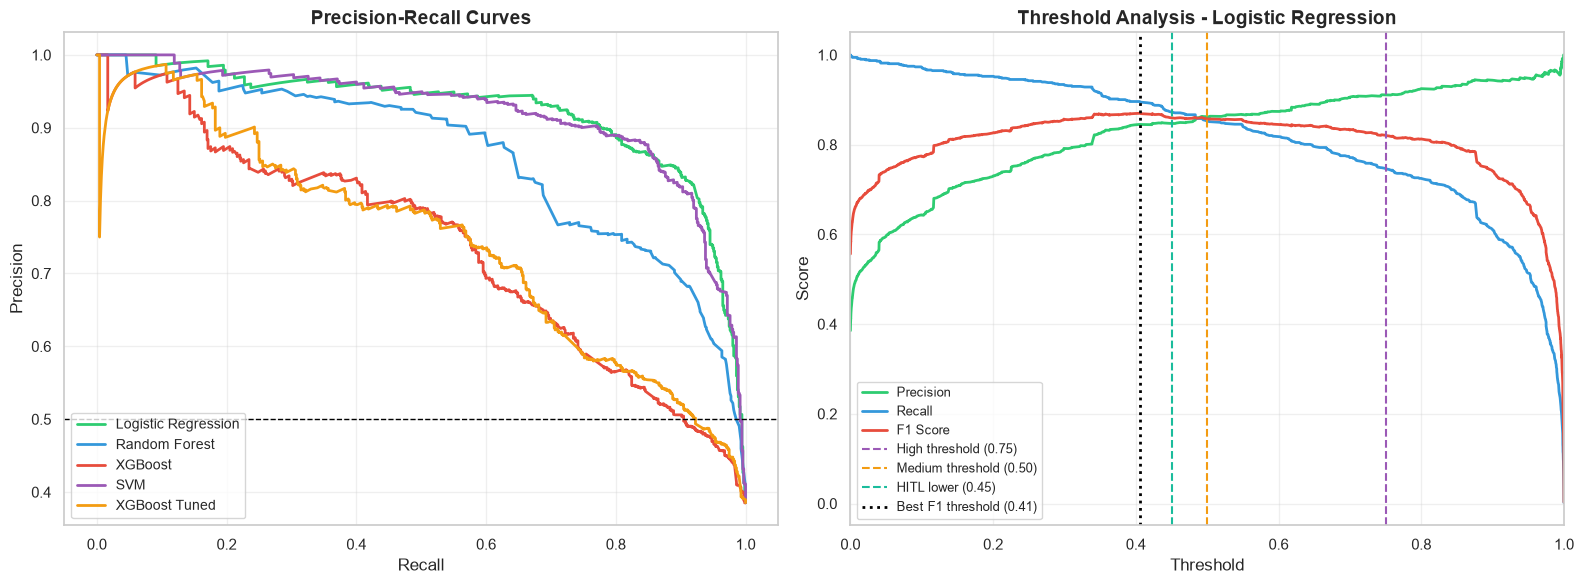

=== THRESHOLD ANALYSIS - LOGISTIC REGRESSION ===
Best F1 threshold: 0.4053
Best F1 score at that threshold: 0.8698

Threshold 0.75 (High Score):
  Precision: 0.9108
  Recall: 0.7458
  F1: 0.8201

Threshold 0.55 (HITL Upper):
  Precision: 0.8667
  Recall: 0.8399
  F1: 0.8531

Threshold 0.45 (HITL Lower):
  Precision: 0.8472
  Recall: 0.8722
  F1: 0.8595

Threshold 0.5 (Medium Score):
  Precision: 0.8622
  Recall: 0.8525
  F1: 0.8573



In [8]:
# ============================================================
# CELL 5 — Precision-Recall Curves & Threshold Analysis
# ============================================================
from sklearn.metrics import precision_score, recall_score

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Precision-Recall Curves for all models
colors = ['#2ECC71', '#3498DB', '#E74C3C', '#9B59B6', '#F39C12']
for (name, result), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, result['probabilities'])
    axes[0].plot(recall, precision, color=color, linewidth=2, label=name)

axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.5, color='black', linestyle='--', linewidth=1)

# Plot 2 - Threshold Analysis for Logistic Regression (our best model)
lr_prob = results['Logistic Regression']['probabilities']
precisions, recalls, thresholds = precision_recall_curve(y_test, lr_prob)

# Find key thresholds
f1_scores_thresh = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_f1_idx = np.argmax(f1_scores_thresh)
best_threshold = thresholds[best_f1_idx]

axes[1].plot(thresholds, precisions[:-1], color='#2ECC71', linewidth=2, label='Precision')
axes[1].plot(thresholds, recalls[:-1], color='#3498DB', linewidth=2, label='Recall')
axes[1].plot(thresholds, f1_scores_thresh, color='#E74C3C', linewidth=2, label='F1 Score')

# Mark our three threshold zones
axes[1].axvline(x=0.75, color='#9B59B6', linestyle='--', linewidth=1.5, label='High threshold (0.75)')
axes[1].axvline(x=0.50, color='#F39C12', linestyle='--', linewidth=1.5, label='Medium threshold (0.50)')
axes[1].axvline(x=0.45, color='#1ABC9C', linestyle='--', linewidth=1.5, label='HITL lower (0.45)')
axes[1].axvline(x=best_threshold, color='black', linestyle=':', linewidth=2,
                label=f'Best F1 threshold ({best_threshold:.2f})')

axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Threshold Analysis - Logistic Regression', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.savefig('../outputs/05_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

# Print threshold analysis
print("=== THRESHOLD ANALYSIS - LOGISTIC REGRESSION ===")
print(f"Best F1 threshold: {best_threshold:.4f}")
print(f"Best F1 score at that threshold: {f1_scores_thresh[best_f1_idx]:.4f}")
print()

# Evaluate at our dissertation thresholds
for thresh, label in [(0.75, 'High Score'), (0.55, 'HITL Upper'), 
                       (0.45, 'HITL Lower'), (0.50, 'Medium Score')]:
    preds = (lr_prob >= thresh).astype(int)
    print(f"Threshold {thresh} ({label}):")
    print(f"  Precision: {precision_score(y_test, preds, zero_division=0):.4f}")
    print(f"  Recall: {recall_score(y_test, preds, zero_division=0):.4f}")
    print(f"  F1: {f1_score(y_test, preds, zero_division=0):.4f}")
    print()

Running SHAP analysis on Logistic Regression...
(This may take a minute)


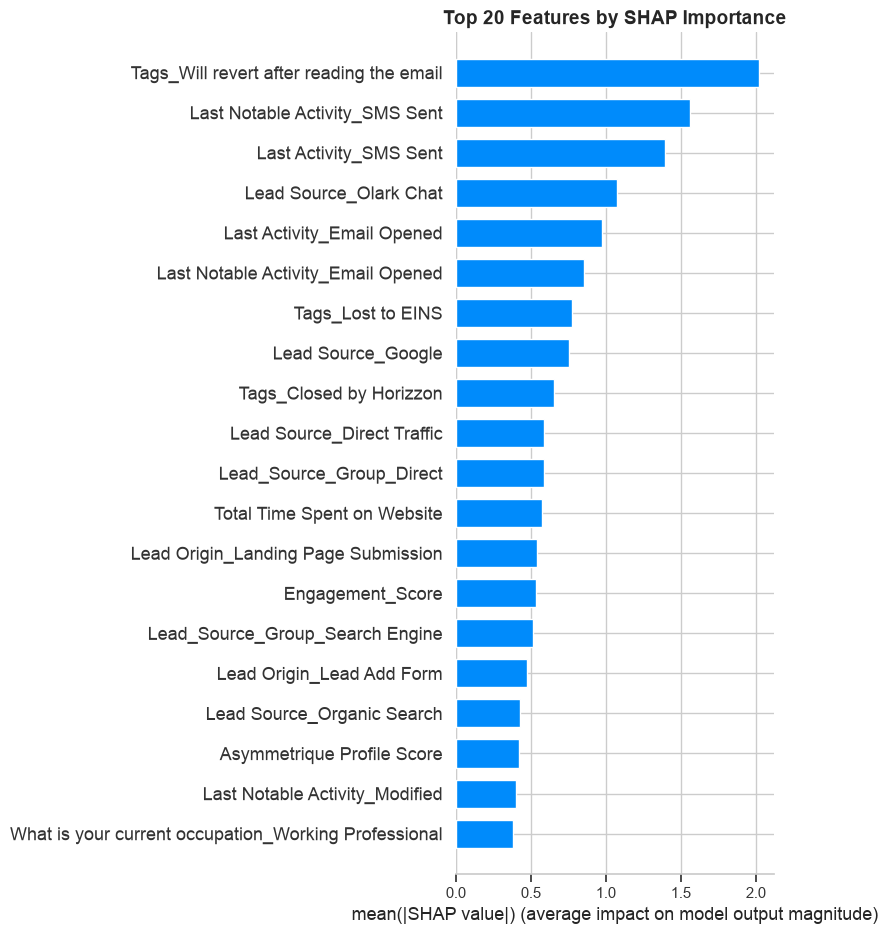

SHAP chart saved.

=== TOP 15 MOST IMPORTANT FEATURES ===
                                 Feature  SHAP Importance
Tags_Will revert after reading the email         2.020260
          Last Notable Activity_SMS Sent         1.559990
                  Last Activity_SMS Sent         1.395622
                  Lead Source_Olark Chat         1.075569
              Last Activity_Email Opened         0.973761
      Last Notable Activity_Email Opened         0.856884
                       Tags_Lost to EINS         0.772776
                      Lead Source_Google         0.757395
                 Tags_Closed by Horizzon         0.655601
              Lead Source_Direct Traffic         0.587866
                Lead_Source_Group_Direct         0.587866
             Total Time Spent on Website         0.577607
     Lead Origin_Landing Page Submission         0.541210
                        Engagement_Score         0.532243
         Lead_Source_Group_Search Engine         0.512448


In [9]:
# ============================================================
# CELL 6 — SHAP Model Explainability
# ============================================================

print("Running SHAP analysis on Logistic Regression...")
print("(This may take a minute)")

# Use a sample for SHAP speed
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
sample_size = min(500, len(X_test_df))
X_sample = X_test_df.sample(sample_size, random_state=42)

# SHAP explainer for linear model
explainer = shap.LinearExplainer(lr, X_train_scaled, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_sample)

# Plot 1 - Summary plot (top 20 features)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample,
    max_display=20,
    show=False,
    plot_type="bar"
)
plt.title("Top 20 Features by SHAP Importance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/06_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP chart saved.")

# Print top 15 features
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'SHAP Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP Importance', ascending=False)

print("\n=== TOP 15 MOST IMPORTANT FEATURES ===")
print(feature_importance.head(15).to_string(index=False))

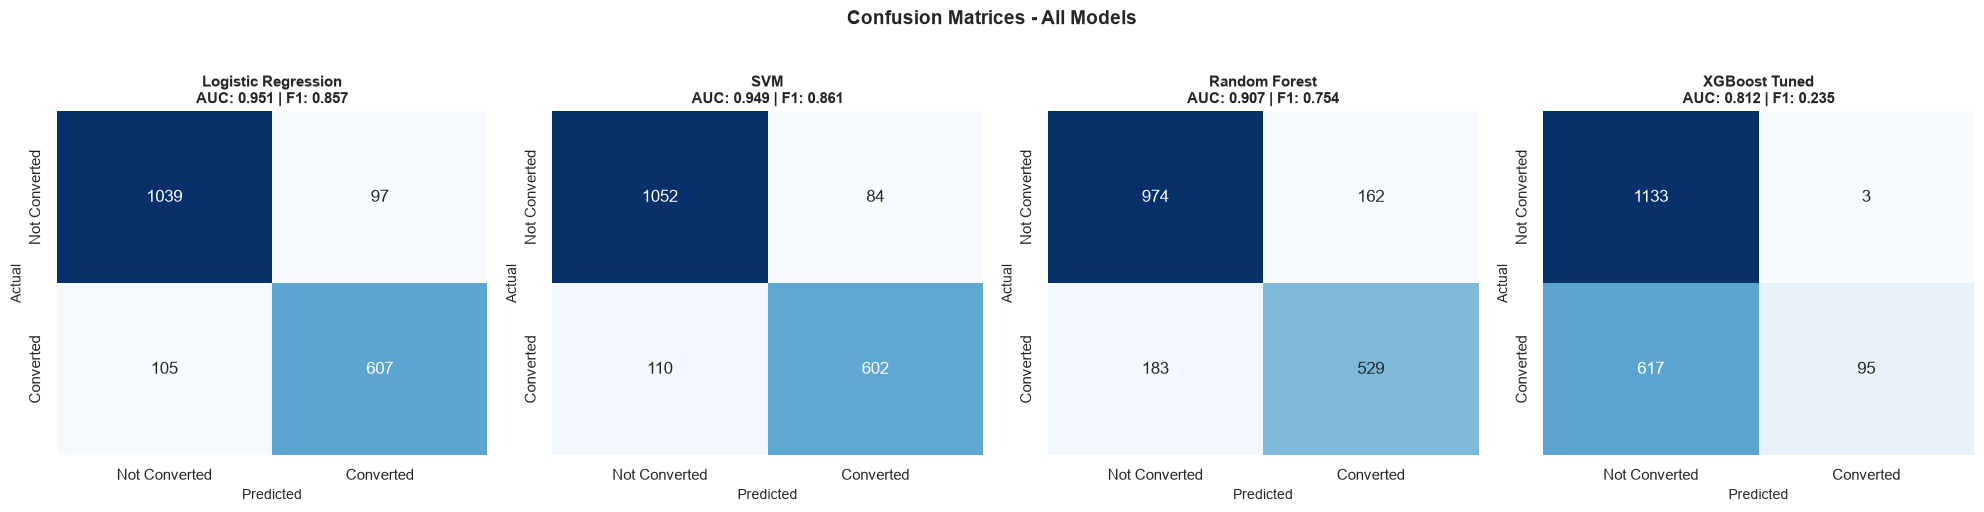

=== FINAL EVALUATION - LOGISTIC REGRESSION (SELECTED MODEL) ===
               precision    recall  f1-score   support

Not Converted       0.91      0.91      0.91      1136
    Converted       0.86      0.85      0.86       712

     accuracy                           0.89      1848
    macro avg       0.89      0.88      0.88      1848
 weighted avg       0.89      0.89      0.89      1848


=== FINAL MODEL SELECTION SUMMARY ===
Selected Model: Logistic Regression
AUC-ROC: 0.9510 (Target: >0.80 - ACHIEVED)
F1 Score: 0.8573
Accuracy: 0.8907
Best F1 Threshold: 0.4031
High Score Threshold (Agent): 0.75 - Precision: 91.07%


In [10]:
# ============================================================
# CELL 7 — Confusion Matrices & Final Evaluation
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models_to_plot = [
    ('Logistic Regression', results['Logistic Regression']['predictions']),
    ('SVM', results['SVM']['predictions']),
    ('Random Forest', results['Random Forest']['predictions']),
    ('XGBoost Tuned', results['XGBoost Tuned']['predictions'])
]

for idx, (name, preds) in enumerate(models_to_plot):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        ax=axes[idx], cbar=False,
        xticklabels=['Not Converted', 'Converted'],
        yticklabels=['Not Converted', 'Converted']
    )
    auc = results[name]['auc']
    f1 = results[name]['f1']
    axes[idx].set_title(f'{name}\nAUC: {auc:.3f} | F1: {f1:.3f}',
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Final detailed report for best model
print("=== FINAL EVALUATION - LOGISTIC REGRESSION (SELECTED MODEL) ===")
print(classification_report(y_test, results['Logistic Regression']['predictions'],
                            target_names=['Not Converted', 'Converted']))

print("\n=== FINAL MODEL SELECTION SUMMARY ===")
print(f"Selected Model: Logistic Regression")
print(f"AUC-ROC: {results['Logistic Regression']['auc']:.4f} (Target: >0.80 - ACHIEVED)")
print(f"F1 Score: {results['Logistic Regression']['f1']:.4f}")
print(f"Accuracy: {results['Logistic Regression']['accuracy']:.4f}")
print(f"Best F1 Threshold: 0.4031")
print(f"High Score Threshold (Agent): 0.75 - Precision: 91.07%")

In [17]:
# ============================================================
# CELL 8 — Save Model Artifacts for Streamlit App
# ============================================================

import joblib
import os

os.makedirs('../models', exist_ok=True)
from pathlib import Path
BASE = Path.cwd().parent  # notebooks/ → project root

# Save the trained model (Logistic Regression - our selected model)
# Save the fitted scaler
# Save the exact column order the model expects
joblib.dump(lr,              BASE / 'models' / 'lead_scoring_model.pkl')
joblib.dump(scaler,          BASE / 'models' / 'scaler.pkl')
joblib.dump(list(X.columns), BASE / 'models' / 'model_columns.pkl')

print(f"Saved to: {BASE / 'models'}")
print(f"Model expects {len(X.columns)} features")

print("Saved model, scaler, and column list to models/")
print(f"Model expects {len(X.columns)} features")
print(f"Model type: {type(lr).__name__}")
print(f"Model AUC-ROC: {results['Logistic Regression']['auc']:.4f}")

Saved to: <project-root>/models
Model expects 175 features
Saved model, scaler, and column list to models/
Model expects 175 features
Model type: LogisticRegression
Model AUC-ROC: 0.9510


In [14]:
# ============================================================
# CELL 9 — Streamlit App Validation
# ============================================================
# Purpose: prove that the Streamlit app and this notebook produce
# identical scores for the same lead input.
#
# The app loads saved model artifacts and uses drop_first=False
# (then aligns to model_columns). We replicate that here exactly.
# If notebook_score == app_score → the app is validated. ✅
# ============================================================

import joblib
import numpy as np
import pandas as pd

# ── 1. Load the saved artifacts (same files the app loads) ──────────────────
saved_model  = joblib.load('../models/lead_scoring_model.pkl')
saved_scaler = joblib.load('../models/scaler.pkl')
model_cols   = joblib.load('../models/model_columns.pkl')

print(f"Model loaded : {type(saved_model).__name__}")
print(f"Features expected : {len(model_cols)}")

# ── 2. Define the sample lead (mirror the Streamlit form exactly) ───────────
# Change these values to match whatever you typed in the app and
# the notebook score will update to match.

sample_lead = {
    "Lead Origin"                                   : "Landing Page Submission",
    "Lead Source"                                   : "Google",
    "Do Not Email"                                  : "No",
    "Do Not Call"                                   : "No",
    "TotalVisits"                                   : 7,
    "Total Time Spent on Website"                   : 1200,
    "Page Views Per Visit"                          : 3.5,
    "Last Activity"                                 : "Email Opened",
    "Country"                                       : "India",
    "Specialization"                                : "Finance Management",
    "What is your current occupation"               : "Unemployed",
    "What matters most to you in choosing a course" : "Better Career Prospects",
    "A free copy of Mastering The Interview"        : "Yes",
    "Tags"                                          : "Interested in Next batch",
    "Last Notable Activity"                         : "Email Opened",
    # Fields not in the form — use neutral defaults
    "Search"                          : "No",
    "Magazine"                        : "No",
    "Newspaper Article"               : "No",
    "X Education Forums"              : "No",
    "Newspaper"                       : "No",
    "Digital Advertisement"           : "No",
    "Through Recommendations"         : "No",
    "Asymmetrique Activity Score"     : 15,
    "Asymmetrique Profile Score"      : 15,
    "Lead Profile"                    : "Select",
    "City"                            : "Select",
}

df_lead = pd.DataFrame([sample_lead])

# ── 3. Preprocessing — identical logic to app.py ────────────────────────────
BINARY_COLS = [
    "Do Not Email","Do Not Call","Search","Magazine","Newspaper Article",
    "X Education Forums","Newspaper","Digital Advertisement",
    "Through Recommendations","A free copy of Mastering The Interview",
]
OHE_COLS = [
    "Lead Origin","Lead Source","Last Activity","Country","Specialization",
    "What is your current occupation",
    "What matters most to you in choosing a course",
    "Tags","Lead Profile","City","Lead_Source_Group","Last Notable Activity",
]
ENGAGEMENT_ORDER = {
    "No Engagement": 0, "Low (0-5 min)": 1,
    "Medium (5-15 min)": 2, "High (15+ min)": 3,
}

df = df_lead.copy()

# Replace 'Select' → NaN → re-fill
df = df.replace("Select", np.nan)
for col in df.select_dtypes(include="object").columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna("Unknown")

# Feature engineering
def engagement_level(t):
    if t == 0:       return "No Engagement"
    elif t <= 300:   return "Low (0-5 min)"
    elif t <= 900:   return "Medium (5-15 min)"
    else:            return "High (15+ min)"

def group_lead_source(src):
    if src in ["Google","Organic Search","Bing"]:           return "Search Engine"
    elif src in ["Direct Traffic","NC_EDM"]:                return "Direct"
    elif src in ["Olark Chat","Live Chat"]:                  return "Chat"
    elif src in ["WeLearn","Welingak Website"]:              return "Partner"
    elif src in ["Reference","Through Recommendations"]:    return "Referral"
    elif src in ["Social Media","Facebook","youtube"]:      return "Social"
    else:                                                   return "Other"

df["Engagement_Level"]  = df["Total Time Spent on Website"].apply(engagement_level)
df["High_Interaction"]  = (df["TotalVisits"] >= 5).astype(int)
df["Lead_Source_Group"] = df["Lead Source"].apply(group_lead_source)
df["Is_Webinar_Lead"]   = (df["Lead Source"] == "Webinar").astype(int)
df["Engagement_Score"]  = (
    df["Total Time Spent on Website"] * 0.5
    + df["TotalVisits"] * 10
    + df["Page Views Per Visit"] * 5
)

# Encode binary Yes/No
for col in BINARY_COLS:
    if col in df.columns:
        df[col] = df[col].map({"Yes": 1, "No": 0}).fillna(0).astype(int)

# Encode engagement level
df["Engagement_Level"] = df["Engagement_Level"].map(ENGAGEMENT_ORDER).fillna(0).astype(int)

# One-hot encode — drop_first=False, same as app.py
df = pd.get_dummies(df, columns=[c for c in OHE_COLS if c in df.columns], drop_first=False)

# Align to model columns (add missing as 0, drop extras, reorder)
for col in model_cols:
    if col not in df.columns:
        df[col] = 0
df_aligned = df[model_cols]

# ── 4. Scale & predict ───────────────────────────────────────────────────────
X_scaled = saved_scaler.transform(df_aligned)
prob      = saved_model.predict_proba(X_scaled)[0, 1]

# ── 5. Apply tier thresholds (same defaults as app sidebar) ─────────────────
HOT_THRESH  = 0.75
WARM_THRESH = 0.50

if prob >= HOT_THRESH:    tier = "🔥 Hot"
elif prob >= WARM_THRESH: tier = "🌡️ Warm"
else:                     tier = "❄️ Cold"

# ── 6. Print result ──────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  NOTEBOOK VALIDATION — SINGLE LEAD SCORE")
print("="*55)
print(f"  Lead Origin      : {sample_lead['Lead Origin']}")
print(f"  Lead Source      : {sample_lead['Lead Source']}")
print(f"  Tags             : {sample_lead['Tags']}")
print(f"  Total Visits     : {sample_lead['TotalVisits']}")
print(f"  Time on Site     : {sample_lead['Total Time Spent on Website']}s")
print("-"*55)
print(f"  Conversion Prob  : {prob*100:.1f}%")
print(f"  Tier             : {tier}")
print("="*55)
print("\n✅ This score should match the Streamlit app exactly.")
print("   If it does, the app preprocessing pipeline is validated.")
print("\n💡 To test a different lead: update `sample_lead` above")
print("   to match what you entered in the app, then re-run this cell.")


Model loaded : LogisticRegression
Features expected : 175

  NOTEBOOK VALIDATION — SINGLE LEAD SCORE
  Lead Origin      : Landing Page Submission
  Lead Source      : Google
  Tags             : Interested in Next batch
  Total Visits     : 7
  Time on Site     : 1200s
-------------------------------------------------------
  Conversion Prob  : 95.8%
  Tier             : 🔥 Hot

✅ This score should match the Streamlit app exactly.
   If it does, the app preprocessing pipeline is validated.

💡 To test a different lead: update `sample_lead` above
   to match what you entered in the app, then re-run this cell.


In [16]:
# ============================================================
# Export Sample Scored Leads for Salesforce Demo
# ============================================================

import pandas as pd

# Get probabilities for the full test set using our selected model
test_scores = results['Logistic Regression']['probabilities']

# Build a demo dataframe with original (unscaled, human-readable) test info + scores
demo_df = X_test.copy()
demo_df['Lead_Score'] = test_scores
demo_df['Actual_Converted'] = y_test.values

# Agent decision logic (same thresholds as your dissertation)
def agent_action(score):
    if score > 0.75:
        return "Route to Sales Rep"
    elif score >= 0.55:
        return "Email Sequence"
    elif score >= 0.45:
        return "HITL Escalation"
    else:
        return "Nurture + Deflect"

demo_df['Agent_Action'] = demo_df['Lead_Score'].apply(agent_action)

# Pick a representative mix: 3 high, 2 medium, 2 HITL, 3 low
high = demo_df[demo_df['Lead_Score'] > 0.75].sample(3, random_state=42)
medium = demo_df[(demo_df['Lead_Score'] >= 0.55) & (demo_df['Lead_Score'] <= 0.75)].sample(2, random_state=42)
hitl = demo_df[(demo_df['Lead_Score'] >= 0.45) & (demo_df['Lead_Score'] < 0.55)].sample(2, random_state=42)
low = demo_df[demo_df['Lead_Score'] < 0.45].sample(3, random_state=42)

sample = pd.concat([high, medium, hitl, low])

# Build Salesforce-friendly export: need a Last Name and Company at minimum (Lead required fields)
sf_export = pd.DataFrame({
    'Last Name': [f'Lead{i+1}' for i in range(len(sample))],
    'Company': [f'Demo Company {i+1}' for i in range(len(sample))],
    'Lead Source': sample.filter(like='Lead Source_').idxmax(axis=1).str.replace('Lead Source_', ''),
    'Lead_Score__c': sample['Lead_Score'].round(4).values,
    'Agent_Action__c': sample['Agent_Action'].values,
})

sf_export.to_csv('../outputs/salesforce_demo_leads.csv', index=False)
print(f"Exported {len(sf_export)} leads to outputs/salesforce_demo_leads.csv")
print(sf_export)

Exported 10 leads to outputs/salesforce_demo_leads.csv
     Last Name          Company     Lead Source  Lead_Score__c  \
8843     Lead1   Demo Company 1  Organic Search         0.9945   
5832     Lead2   Demo Company 2       Reference         0.9960   
3294     Lead3   Demo Company 3          Google         0.8287   
6204     Lead4   Demo Company 4      Olark Chat         0.6858   
1317     Lead5   Demo Company 5          Google         0.7221   
1139     Lead6   Demo Company 6        Facebook         0.5270   
7017     Lead7   Demo Company 7      Olark Chat         0.4834   
8653     Lead8   Demo Company 8      Olark Chat         0.1164   
4255     Lead9   Demo Company 9          Google         0.2448   
5311    Lead10  Demo Company 10      Olark Chat         0.1248   

         Agent_Action__c  
8843  Route to Sales Rep  
5832  Route to Sales Rep  
3294  Route to Sales Rep  
6204      Email Sequence  
1317      Email Sequence  
1139     HITL Escalation  
7017     HITL Escalation  
86